In [20]:
import pandas as pd 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np 
from models import PCA_Scratch
from models import NaiveBayes_Scratch

In [21]:
# Loading the first dataset
df = pd.read_csv('data/Students Social Media Addiction.csv')

In [22]:
# Loading the second dataset
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df2 = pd.DataFrame(data.data, columns=data.feature_names)
y2 = data.target # 0: Malignant, 1: Benign

In [23]:
from sklearn.model_selection import train_test_split

# 1. Define  X (Features) and y (Target)
X2 = df2.values
y2_binary = y2 # 

# 2. Scale the data 
X2_mean = np.mean(X2, axis=0)
X2_std = np.std(X2, axis=0)
X2_scaled = (X2 - X2_mean) / (X2_std + 1e-9)

In [24]:
from sklearn.preprocessing import LabelEncoder

# 1. Separate our target (what we want to predict)
y = df['Addicted_Score'].values

# 2. Identify Categorical vs Numerical columns
categorical_cols = ['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform', 
                    'Affects_Academic_Performance', 'Relationship_Status']

numerical_cols = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 
                  'Mental_Health_Score', 'Conflicts_Over_Social_Media']

# 3. Convert Categorical Text to Numbers (Label Encoding) (0/1)
df_encoded = df.copy()
le = LabelEncoder()

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df[col])

# 4. Create our feature matrices
X_numerical = df_encoded[numerical_cols].values
X_categorical = df_encoded[categorical_cols].values

print("Numerical features shape:", X_numerical.shape)
print("Categorical features shape:", X_categorical.shape)

Numerical features shape: (705, 5)
Categorical features shape: (705, 6)


In [25]:
# Standardize the numerical data
# Formula: z = (x - mean) / std

X_mean = np.mean(X_numerical, axis=0)
X_std = np.std(X_numerical, axis=0)

# We use 1e-9 to avoid division by zero if a column has zero variance
X_numerical_scaled = (X_numerical - X_mean) / (X_std + 1e-9)


c:\Yusuf\Faculty\Third Year\Second Semester\Supervised Learning\Assignments\Assignment 1\Naive-Bayes-Classifier-PCA\models.py:93: RuntimeWarning: divide by zero encountered in log
  return np.log(numerator / denominator)


--- EXPERIMENT 0: BASELINE RESULTS ---
Accuracy: 99.29%
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      0.99      0.99        88

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



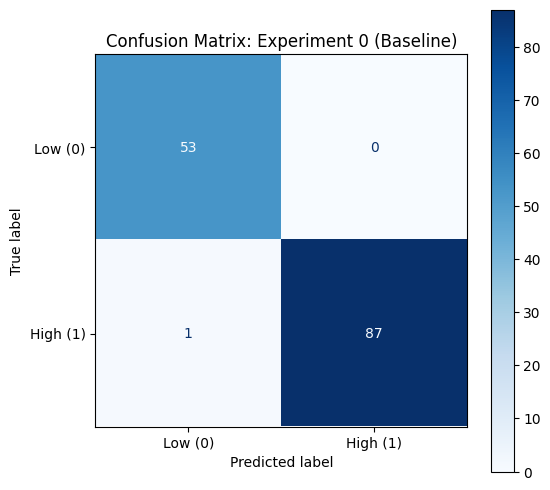

In [26]:
# Experiment 0 [Baseline] [First Dataset]

# 1.Combining the numerical scaled values and the categorical values 
X_all = np.hstack((X_numerical_scaled, X_categorical))

# 2. Split the combined data
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_all, y_binary, test_size=0.2, random_state=42)

# 3. Train
nb_baseline = NaiveBayes_Scratch(model_type='gaussian')
nb_baseline.fit(X_train_0, y_train_0)

# 4. Predict & Evaluate
y_pred_0 = nb_baseline.predict(X_test_0)

print("--- EXPERIMENT 0: BASELINE RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test_0, y_pred_0)*100:.2f}%")
print(classification_report(y_test_0, y_pred_0))

# 5. Confusion Matrix using Matplotlib + Sklearn (No Seaborn required)
cm_0 = confusion_matrix(y_test_0, y_pred_0)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_0, display_labels=['Low (0)', 'High (1)'])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d') # 'd' displays raw counts
plt.title('Confusion Matrix: Experiment 0 (Baseline)')
plt.show()

--- EXPERIMENT A: FEATURE SELECTION RESULTS ---
Accuracy: 99.29%

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        53
           1       1.00      0.99      0.99        88

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



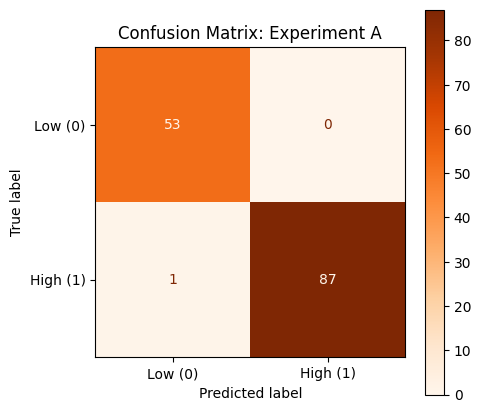

In [27]:
# Experiment A [feature selection + Naive Bayes]

# I have selected feature no.1 and no.4 [1: Avg_Daily_Usage_Hours, 4: Conflicts_Over_Social_Media]
X_selected = X_numerical_scaled[:, [1, 4]] 

# 7. Train using ONLY these features
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_selected, y_binary, test_size=0.2, random_state=42)

nb_A = NaiveBayes_Scratch(model_type='gaussian')
nb_A.fit(X_train_A, y_train_A)

# 8. Predict
y_pred_A = nb_A.predict(X_test_A)

# Evaluation 1: Accuracy
print("--- EXPERIMENT A: FEATURE SELECTION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test_A, y_pred_A)*100:.2f}%")

# Evaluation 2: Classification Report (Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_test_A, y_pred_A))

# Evaluation 3: Confusion Matrix
cm_A = confusion_matrix(y_test_A, y_pred_A)
disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=['Low (0)', 'High (1)'])

# Using a different color (Oranges) to distinguish from the Baseline
fig, ax = plt.subplots(figsize=(5, 5))
disp_A.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Confusion Matrix: Experiment A')
plt.show()

PCA with k=1 | Accuracy: 95.74%
PCA with k=2 | Accuracy: 96.45%
PCA with k=3 | Accuracy: 97.87%
PCA with k=4 | Accuracy: 97.87%

--- Final Evaluation for Best Performing k (3) ---

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97        53
           1       0.99      0.98      0.98        88

    accuracy                           0.98       141
   macro avg       0.98      0.98      0.98       141
weighted avg       0.98      0.98      0.98       141



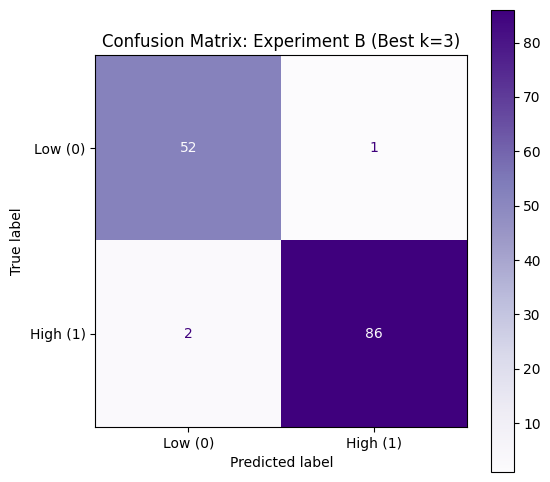

In [28]:
# Experiment B [PCA + Naive Bayes]

best_k = 0
best_acc = 0

for k in [1, 2, 3, 4]:
    # 1. Initialize the PCA with k components
    pca = PCA_Scratch(n_components= k)

    # 2. Fit and transform the numerical data
    X_pca = pca.fit_transform(X_numerical_scaled)

    # Train Naive Bayes
    X_tr, X_te, y_tr, y_te = train_test_split(X_pca, y_binary, test_size=0.2, random_state=42)
    model = NaiveBayes_Scratch(model_type='gaussian')
    model.fit(X_tr, y_tr)
    
    # Results
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"PCA with k={k} | Accuracy: {acc*100:.2f}%")
    
    # Keep track of the best performing k for the final evaluation
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_y_test = y_te
        best_y_pred = y_pred

# --- Evaluation of the best k ---
print(f"\n--- Final Evaluation for Best Performing k ({best_k}) ---")

# 1. Classification Report
print("\nClassification Report:\n", classification_report(best_y_test, best_y_pred))

# 2. Confusion Matrix
cm_B = confusion_matrix(best_y_test, best_y_pred)
disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=['Low (0)', 'High (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp_B.plot(ax=ax, cmap='Purples', values_format='d')
plt.title(f'Confusion Matrix: Experiment B (Best k={best_k})')
plt.show()


--- EXPERIMENT 0: BASELINE RESULTS (Dataset 2) ---
Accuracy: 96.49%
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



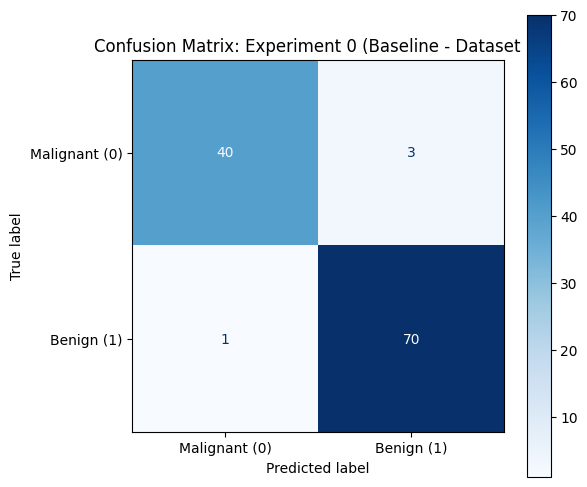

In [29]:
# Experiment 0 [Baseline] [Second Dataset: Breast Cancer]

# 1. For this dataset, all 30 features are numerical and already in X2_scaled
X_all_2 = X2_scaled 

# 2. Split the data (Using y2_binary)
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_all_2, y2_binary, test_size=0.2, random_state=42)

# 3. Train
nb_baseline = NaiveBayes_Scratch(model_type='gaussian')
nb_baseline.fit(X_train_0, y_train_0)

# 4. Predict & Evaluate
y_pred_0 = nb_baseline.predict(X_test_0)

print("--- EXPERIMENT 0: BASELINE RESULTS (Dataset 2) ---")
print(f"Accuracy: {accuracy_score(y_test_0, y_pred_0)*100:.2f}%")
print(classification_report(y_test_0, y_pred_0))

# 5. Confusion Matrix (Labels changed to Malignant/Benign for accuracy)
cm_0 = confusion_matrix(y_test_0, y_pred_0)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_0, display_labels=['Malignant (0)', 'Benign (1)'])

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Experiment 0 (Baseline - Dataset 2)')
plt.show()

--- EXPERIMENT A: FEATURE SELECTION RESULTS (Dataset 2) ---
Accuracy: 94.74%

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        43
           1       0.95      0.97      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



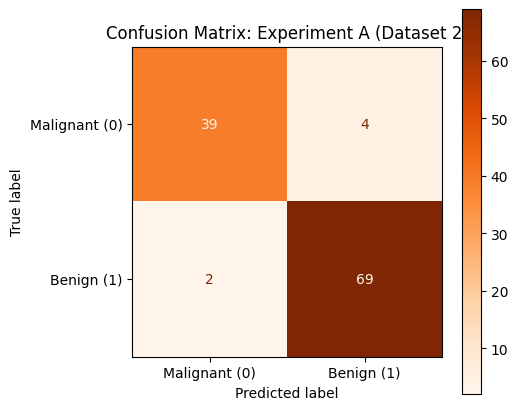

In [30]:
# Experiment A [feature selection + Naive Bayes] [Second Dataset]

# 1. Use the new selection variable you defined
X_selected2 = X2_scaled[:, [0, 27]] 

# 2. Fix the split: Use X_selected2 and y2_binary
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_selected2, y2_binary, test_size=0.2, random_state=42)

# 3. Train using your scratch model
nb_A = NaiveBayes_Scratch(model_type='gaussian')
nb_A.fit(X_train_A, y_train_A)

# 4. Predict
y_pred_A = nb_A.predict(X_test_A)


# Evaluation 1: Accuracy
print("--- EXPERIMENT A: FEATURE SELECTION RESULTS (Dataset 2) ---")
print(f"Accuracy: {accuracy_score(y_test_A, y_pred_A)*100:.2f}%")

# Evaluation 2: Classification Report
print("\nClassification Report:\n", classification_report(y_test_A, y_pred_A))

# Evaluation 3: Confusion Matrix
cm_A = confusion_matrix(y_test_A, y_pred_A)
# Update labels for Cancer Dataset: 0 is Malignant, 1 is Benign
disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=['Malignant (0)', 'Benign (1)'])

fig, ax = plt.subplots(figsize=(5, 5))
disp_A.plot(ax=ax, cmap='Oranges', values_format='d')
plt.title('Confusion Matrix: Experiment A (Dataset 2)')
plt.show()

PCA with k=1 | Accuracy: 92.98%
PCA with k=2 | Accuracy: 94.74%
PCA with k=3 | Accuracy: 94.74%
PCA with k=4 | Accuracy: 94.74%

--- Final Evaluation for Best Performing k (2) ---

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.88      0.93        43
           1       0.93      0.99      0.96        71

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114



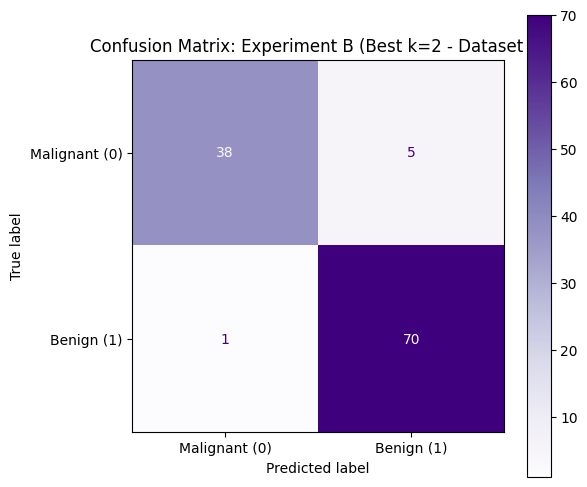

In [31]:
# Experiment B [PCA + Naive Bayes] [Second Dataset]

best_k = 0
best_acc = 0

for k in [1, 2, 3, 4]:
    # 1. Initialize the PCA with k components
    pca = PCA_Scratch(n_components=k)

    # 2. Fit and transform the SECOND dataset numerical data
    X_pca2 = pca.fit_transform(X2_scaled)

    # 3. Train Naive Bayes using y2_binary
    X_tr, X_te, y_tr, y_te = train_test_split(X_pca2, y2_binary, test_size=0.2, random_state=42)
    model = NaiveBayes_Scratch(model_type='gaussian')
    model.fit(X_tr, y_tr)
    
    # Results
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    print(f"PCA with k={k} | Accuracy: {acc*100:.2f}%")
    
    # Keep track of the best performing k for the final evaluation
    if acc > best_acc:
        best_acc = acc
        best_k = k
        best_y_test = y_te
        best_y_pred = y_pred

# --- Evaluation of the best k ---
print(f"\n--- Final Evaluation for Best Performing k ({best_k}) ---")

# 1. Classification Report
print("\nClassification Report:\n", classification_report(best_y_test, best_y_pred))

# 2. Confusion Matrix
cm_B = confusion_matrix(best_y_test, best_y_pred)
# Labels updated for Cancer Dataset
disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=['Malignant (0)', 'Benign (1)'])

# Plotting the matrix
fig, ax = plt.subplots(figsize=(6, 6))
disp_B.plot(ax=ax, cmap='Purples', values_format='d')
plt.title(f'Confusion Matrix: Experiment B (Best k={best_k} - Dataset 2)')
plt.show()